# 02: Qiskit の基本操作

Qiskit で量子回路を作り、状態を確認するまでの最小限の流れを学ぶ。

**内容:**
1. 1量子ビットの回路：$X$ ゲートでビットを反転する
2. 重ね合わせ：$H$ ゲートで $\vert+\rangle$ を作る
3. 2量子ビットのもつれ：ベル状態を作る
4. バリア：回路の区切り
5. 回路の部品化：`append` でゲートを組み込む
6. 測定：量子ビットの値を読み出す
7. 制御ゲート：`control` で制御ビットを付ける
8. 逆操作：`inverse` でゲートを巻き戻す

In [2]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np

## 1. ビット反転：$X$ ゲート

$\vert 0\rangle$ を $\vert 1\rangle$ にひっくり返す、最も単純な回路。

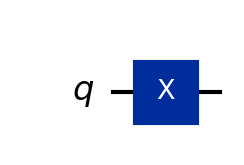

In [3]:
# 1量子ビットの回路を作る
qc = QuantumCircuit(1)

# X ゲート（ビット反転）を掛ける
qc.x(0)

# 状態ベクトルを確認する
sv = Statevector.from_instruction(qc)

print("状態ベクトル:", np.array(sv).round(4))
print()
for i, amp in enumerate(sv):
    print(f"  |q_0⟩ = |{i}⟩ の振幅: {amp:.4f}  確率: {abs(amp)**2:.4f}")

状態ベクトル: [0.+0.j 1.+0.j]

  |q_0⟩ = |0⟩ の振幅: 0.0000+0.0000j  確率: 0.0000
  |q_0⟩ = |1⟩ の振幅: 1.0000+0.0000j  確率: 1.0000


**コードの解説:**

- `QuantumCircuit(1)`: 1量子ビットの空の回路を作る。引数の数字が量子ビット数。初期状態は $\vert 0\rangle$。
- `qc.x(0)`: $q_0$ に $X$ ゲートを適用する。$X\vert 0\rangle = \vert 1\rangle$、$X\vert 1\rangle = \vert 0\rangle$。

**コードの解説:**

- `Statevector.from_instruction(qc)`: 回路を $\vert 0\rangle$ から実行したときの最終状態ベクトルを計算する。実機を使わずシミュレーションで直接求める方法。
- `np.array(sv)`: 状態ベクトルを配列として取得する。1量子ビットなら要素は2つ（$\vert 0\rangle$ と $\vert 1\rangle$ の振幅）。
- `.round(4)`: 配列の各要素を小数点以下4桁に丸める。これがないと `0.70710678+0.j` のように長い桁数で表示されて読みにくい。f文字列中の `:.4f` も同じ目的で、1つの数値を小数点以下4桁で書式化する。
- `abs(amp)**2`: 振幅の絶対値の2乗が測定確率になる（ボルンの規則）。
- 出力中の `j` は虚数単位（数学の $i$）。Python では電気工学の慣習に従い `j` を使う。

$\vert 0\rangle$ の振幅が 0、$\vert 1\rangle$ の振幅が 1 なので、測定すれば 100% の確率で 1 が出る。

## 2. 重ね合わせ：$H$ ゲート

$\vert 0\rangle$ にアダマールゲートを掛けて、$\vert 0\rangle$ と $\vert 1\rangle$ の重ね合わせ $\vert+\rangle = \frac{\vert 0\rangle + \vert 1\rangle}{\sqrt{2}}$ を作る。

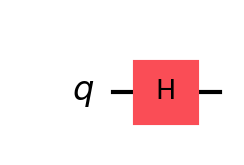

In [4]:
qc2 = QuantumCircuit(1)
qc2.h(0)  # アダマールゲート

# 状態ベクトルを確認
sv2 = Statevector.from_instruction(qc2)

print("状態ベクトル:", np.array(sv2).round(4))
print()
for i, amp in enumerate(sv2):
    print(f"  |q_0⟩ = |{i}⟩ の振幅: {amp:.4f}  確率: {abs(amp)**2:.4f}")

print()
print("→ |0⟩ と |1⟩ の振幅がどちらも 1/√2 ≈ 0.7071。")
print("  測定すると 0 か 1 がそれぞれ 50% の確率で出る。")

状態ベクトル: [0.7071+0.j 0.7071+0.j]

  |q_0⟩ = |0⟩ の振幅: 0.7071+0.0000j  確率: 0.5000
  |q_0⟩ = |1⟩ の振幅: 0.7071+0.0000j  確率: 0.5000

→ |0⟩ と |1⟩ の振幅がどちらも 1/√2 ≈ 0.7071。
  測定すると 0 か 1 がそれぞれ 50% の確率で出る。


**コードの解説:**

- `qc2.h(0)`: $q_0$ にアダマールゲート $H$ を適用する。$H\vert 0\rangle = \frac{\vert 0\rangle + \vert 1\rangle}{\sqrt{2}}$。

## 3. もつれ：ベル状態

2量子ビットで $H$ + CNOT を掛けて、ベル状態 $\frac{\vert 00\rangle + \vert 11\rangle}{\sqrt{2}}$ を作る。

2つのビットが「もつれた」状態になり、一方を測定すると他方の結果も確定する。

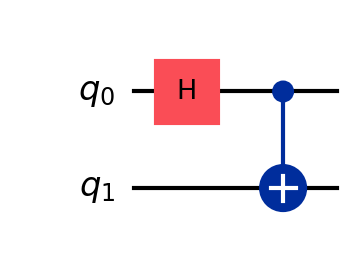

In [5]:
qc3 = QuantumCircuit(2)
qc3.h(0)       # 上のワイヤーに H
qc3.cx(0, 1)   # CNOT: q_0(制御) → q_1(標的)

# 状態ベクトルを確認
sv3 = Statevector.from_instruction(qc3)

print("状態ベクトル:", np.array(sv3).round(4))
print()
for i, amp in enumerate(sv3):
    if abs(amp) > 1e-10:
        q0 = i & 1
        q1 = (i >> 1) & 1
        print(f"  |q_1 q_0⟩ = |{i:02b}⟩ の振幅: {amp:.4f}  → q_0={q0}, q_1={q1}")

print()
print("→ |00⟩ と |11⟩ だけが現れる。")
print("  q_0 を測って 0 なら q_1 も必ず 0。")
print("  q_0 を測って 1 なら q_1 も必ず 1。")
print("  これが量子もつれ（エンタングルメント）である。")

状態ベクトル: [0.7071+0.j 0.    +0.j 0.    +0.j 0.7071+0.j]

  |q_1 q_0⟩ = |00⟩ の振幅: 0.7071+0.0000j  → q_0=0, q_1=0
  |q_1 q_0⟩ = |11⟩ の振幅: 0.7071+0.0000j  → q_0=1, q_1=1

→ |00⟩ と |11⟩ だけが現れる。
  q_0 を測って 0 なら q_1 も必ず 0。
  q_0 を測って 1 なら q_1 も必ず 1。
  これが量子もつれ（エンタングルメント）である。


**コードの解説:**

- `QuantumCircuit(2)`: 2量子ビットの回路。初期状態は $\vert 00\rangle$。
- `qc3.cx(0, 1)`: CNOT ゲート。第1引数が制御ビット、第2引数が標的ビット。制御ビットが $\vert 1\rangle$ のとき標的ビットを反転する。

## 4. バリア：回路の区切り

回路が長くなると、どこからどこまでが1つのまとまりなのか見分けにくくなる。`qc.barrier()` を入れると、回路図に区切り線（破線）が描かれ、論理的なフェーズを視覚的に分けられる。

バリアの後にゲートを追加すると、必ずバリアの右側に配置される。また、Qiskit のトランスパイラ（回路最適化）がバリアを越えてゲートを並べ替えることはない。

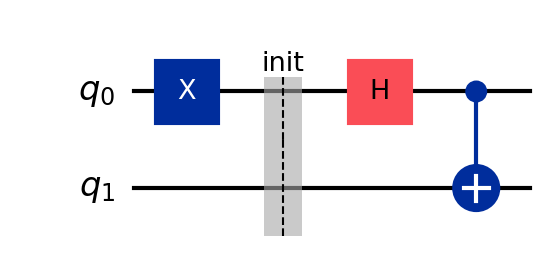

In [ ]:
# バリアの例: 初期化フェーズとベル状態生成を区切る
qc_barrier = QuantumCircuit(2)
qc_barrier.x(0)                    # 初期化: q_0 を |1⟩ にする
qc_barrier.barrier(label="init")    # ここで区切り
qc_barrier.h(0)                    # ベル状態生成: H
qc_barrier.cx(0, 1)                # ベル状態生成: CNOT

print(f"ゲート数: {qc_barrier.size()}（バリアはゲート数に含まれない）")

**コードの解説:**

- `qc.barrier()`: 回路に区切り線を入れる。物理的な操作は何もしない（ユニタリ行列は恒等演算子）。
- `qc.barrier(label="init")`: ラベル付きのバリア。回路図の区切り線の上にラベルが表示される。

後続のノートブック（03 のテレポーテーション回路など）では、回路を「初期化」「Alice の操作」「測定」「Bob の補正」のようにフェーズごとにバリアで区切って見やすくしている。

## 5. 回路の部品化：`append`

後続のノートブックでは、小さな回路を「ゲート」として部品化し、`qc.append()` で大きな回路に組み込むパターンが頻繁に登場する。

ここではセクション3のベル状態回路をゲート化し、3量子ビットの回路に組み込む例を示す。

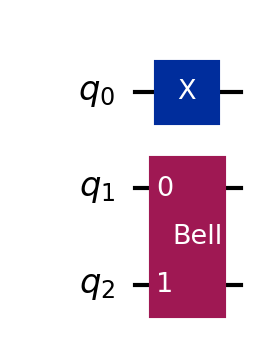

In [6]:
# ベル状態回路を「ゲート」として部品化する
bell = QuantumCircuit(2, name="Bell")
bell.h(0)
bell.cx(0, 1)
bell_gate = bell.to_gate()  # QuantumCircuit → Gate に変換

# 3量子ビットの回路に組み込む
qc4 = QuantumCircuit(3)
qc4.x(0)                        # q_0 を |1⟩ にする
qc4.append(bell_gate, [1, 2])    # q_1, q_2 にベルゲートを適用

# 状態ベクトルを確認
sv4 = Statevector.from_instruction(qc4)
print("状態ベクトル:", np.array(sv4).round(4))
print()
for i, amp in enumerate(sv4):
    if abs(amp) > 1e-10:
        print(f"  |q_2 q_1 q_0⟩ = |{i:03b}⟩ の振幅: {amp:.4f}")

print()
print("→ q_0 は |1⟩ のまま、q_1 と q_2 がベル状態になっている。")

状態ベクトル: [0.    +0.j 0.7071+0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
 0.    +0.j 0.7071+0.j]

  |q_2 q_1 q_0⟩ = |001⟩ の振幅: 0.7071+0.0000j
  |q_2 q_1 q_0⟩ = |111⟩ の振幅: 0.7071+0.0000j

→ q_0 は |1⟩ のまま、q_1 と q_2 がベル状態になっている。


**コードの解説:**

- `bell.to_gate()`: `QuantumCircuit` を `Gate` オブジェクトに変換する。回路図では1つの箱（「Bell」）として表示される。
- `qc4.append(bell_gate, [1, 2])`: ゲートを指定した量子ビットに適用する。リスト `[1, 2]` はゲートの 0 番目の入力を $q_1$ に、1 番目の入力を $q_2$ に接続することを意味する。

**ゲートの追加順と回路図の関係:**

`qc.append()`（や `qc.h()`, `qc.cx()` などのメソッド）で追加した順に、回路図では**左から右へ**配置される。量子回路は左から右へ時間が進むので、先に追加したゲートが先に作用する。

**`QuantumCircuit` と `Gate` の違い:**

Qiskit には「回路」と「ゲート」の2つの概念がある。

| | `QuantumCircuit` | `Gate` |
|---|---|---|
| 役割 | 量子ビットを持ち、ゲートを並べる「設計図」 | 他の回路に部品として組み込める「操作の塊」 |
| 作り方 | `QuantumCircuit(n)` | `circuit.to_gate()` で回路から変換 |
| 使い方 | そのまま実行・シミュレーション | `qc.append(gate, qubits)` で回路に追加 |

`qc.h(0)` や `qc.cx(0, 1)` で使っている $H$ や CNOT も `Gate` である。`.to_gate()` は自分で作った回路を、$H$ や CNOT と同じように扱えるようにする操作。

後続のノートブックでは、逆 QFT やモジュラ乗算などの複雑な操作を `.to_gate()` でゲート化し、`append` で QPE 回路に組み込む。

回路図の「Bell」の箱の中には $H$ と CNOT が入っている。`.decompose()` で中身を展開できる。

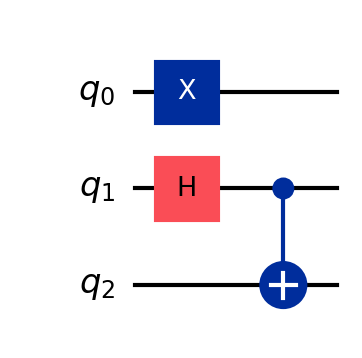

In [7]:
# decompose: Bell ゲートの中身だけを展開する
qc4_decomposed = qc4.decompose("Bell")

print(f"展開前: ゲート数 {qc4.size()}（X + Bell の2つ）")
print(f"展開後: ゲート数 {qc4_decomposed.size()}（X + H + CNOT の3つ）")

展開前: ゲート数 2（X + Bell の2つ）
展開後: ゲート数 3（X + H + CNOT の3つ）


## 6. 測定：量子ビットの値を読み出す

ここまでは `Statevector.from_instruction()` で状態ベクトルを直接見てきた。しかし実際の量子コンピュータでは、量子ビットを**測定**して初めて結果（0 か 1）を得る。測定結果は**古典ビット**に格納される。

測定を使うには、量子ビットとは別に古典ビットを用意する。

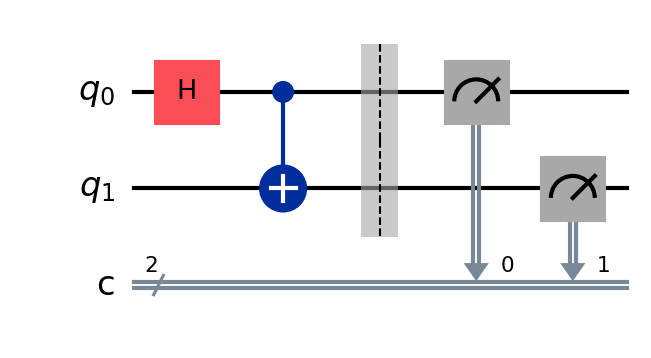

In [8]:
from qiskit import QuantumRegister, ClassicalRegister
from qiskit.primitives import StatevectorSampler

# 量子ビット2つ、古典ビット2つの回路
q = QuantumRegister(2, "q")
c = ClassicalRegister(2, "c")
qc5 = QuantumCircuit(q, c)

# ベル状態を作る
qc5.h(q[0])
qc5.cx(q[0], q[1])
qc5.barrier()

# 測定: 量子ビットの値を古典ビットに書き込む
qc5.measure(q[0], c[0])
qc5.measure(q[1], c[1])

# サンプラーで 1000 回測定する
sampler = StatevectorSampler()
job = sampler.run([qc5], shots=1000)
result = job.result()
counts = result[0].data.c.get_counts()

print("測定結果（1000回）:")
for bitstring, count in sorted(counts.items()):
    print(f"  {bitstring}: {count} 回")
print()
print("→ 00 と 11 がほぼ半々。01 や 10 は出ない（もつれているから）。")

測定結果（1000回）:
  00: 484 回
  11: 516 回

→ 00 と 11 がほぼ半々。01 や 10 は出ない（もつれているから）。


**コードの解説:**

- `QuantumRegister(2, "q")`: 名前付きの量子レジスタを作る。`QuantumCircuit(2)` でも量子ビットは作れるが、レジスタに名前を付けると回路図が読みやすくなる。
- `ClassicalRegister(2, "c")`: 古典レジスタ。測定結果を格納する入れ物。量子ビットとは独立に作る。
- `QuantumCircuit(q, c)`: 量子レジスタと古典レジスタを渡して回路を作る。
- `qc5.measure(q[0], c[0])`: $q_0$ を測定し、結果（0 か 1）を $c_0$ に書き込む。
- `StatevectorSampler()`: Qiskit の状態ベクトルシミュレータで測定を行うサンプラー。実機と同じように「何回か測定して結果を集計する」動作をシミュレーションで再現する。
- `sampler.run([qc5], shots=1000)`: 回路を 1000 回実行（測定）する。回路はリストで渡す。
- `result[0].data.c.get_counts()`: 古典レジスタ `c` の測定結果を集計した辞書。キーがビット列、値が出現回数。

**`Statevector.from_instruction()` との違い:**

| | `Statevector.from_instruction()` | `StatevectorSampler` |
|---|---|---|
| 返すもの | 状態ベクトル（振幅の配列） | 測定結果の集計（ビット列と回数） |
| 確率 | 振幅から計算で求める | 実際に何度も測定して数える |
| 測定の影響 | 測定なし（状態を壊さない） | 測定あり（状態が崩壊する） |
| 用途 | 状態の中身を正確に調べたいとき | 実機と同じ測定結果を得たいとき |

## 7. 制御ゲート：`control` で制御ビットを付ける

`.control()` を使うと、任意のゲートに制御ビットを追加できる。制御ビットが $\vert 1\rangle$ のときだけゲートが作用する。

CNOT（`cx`）は $X$ ゲートに制御ビットを1つ付けたものだから、`x.control(1)` で同じゲートが作れる。

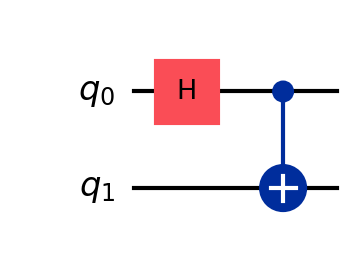

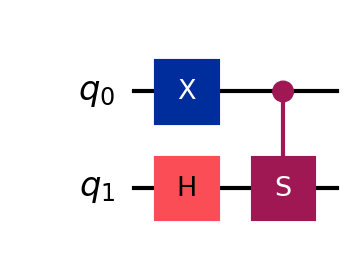

In [10]:
from qiskit.circuit.library import XGate, SGate

# --- 例1: X ゲートに制御ビットを付ける → CNOT と同じ ---
cx_gate = XGate().control(1)

qc6 = QuantumCircuit(2)
qc6.h(0)                        # q_0 を重ね合わせにする
qc6.append(cx_gate, [0, 1])     # [制御, 標的]

sv6 = Statevector.from_instruction(qc6)
print("例1: X.control(1) = CNOT")
print("状態ベクトル:", np.array(sv6).round(4))
for i, amp in enumerate(sv6):
    if abs(amp) > 1e-10:
        print(f"  |{i:02b}⟩: {amp:.4f}")

print()

# --- 例2: 自作ゲートに制御ビットを付ける ---
# S ゲート（π/2 位相回転）に制御ビットを付ける
cs_gate = SGate().control(1)

qc7 = QuantumCircuit(2)
qc7.x(0)                        # 制御ビットを |1⟩ にする
qc7.h(1)                        # 標的を重ね合わせにする
qc7.append(cs_gate, [0, 1])     # 制御が |1⟩ なので S が作用する

sv7 = Statevector.from_instruction(qc7)
print("例2: S.control(1) — 制御ビットが |1⟩ なので S が作用")
print("状態ベクトル:", np.array(sv7).round(4))
for i, amp in enumerate(sv7):
    if abs(amp) > 1e-10:
        print(f"  |{i:02b}⟩: {amp:.4f}")

例1: X.control(1) = CNOT
状態ベクトル: [0.7071+0.j 0.    +0.j 0.    +0.j 0.7071+0.j]
  |00⟩: 0.7071+0.0000j
  |11⟩: 0.7071+0.0000j

例2: S.control(1) — 制御ビットが |1⟩ なので S が作用
状態ベクトル: [0.    +0.j     0.7071+0.j     0.    +0.j     0.    +0.7071j]
  |01⟩: 0.7071+0.0000j
  |11⟩: 0.0000+0.7071j


**コードの解説:**

- `XGate()`: $X$ ゲートのオブジェクトを取得する。`qc.x(0)` のメソッド版とは異なり、回路に追加せず単体のゲートとして扱える。
- `XGate().control(1)`: $X$ ゲートに制御ビットを1つ付ける。結果は CNOT と同じ動作をする。引数の `1` はビット番号ではなく、付ける制御ビットの**個数**。どの量子ビットを制御にするかは `append` の引数で指定する。
- `SGate().control(1)`: $S$ ゲート（$\vert 1\rangle$ に $e^{i\pi/2} = i$ の位相を付ける）に制御ビットを付ける。
- `qc.append(gate, [0, 1])`: 制御ゲートでは、リストの最初が制御ビット、残りが標的ビット。

`.control()` は任意のゲートに使えるので、自作ゲート（`.to_gate()` で作ったもの）にも制御ビットを付けられる。後続の QPE ノートブックでは、位相ゲートに制御ビットを付けて制御ユニタリ $C\text{-}U$ を構成する。

## 8. 逆操作：`inverse` でゲートを巻き戻す

`.inverse()` はゲートの逆操作（随伴 $U^\dagger$）を返す。$U$ の後に $U^\dagger$ を掛けると元の状態に戻る：$U^\dagger U = I$。

ここでは $H$ + CNOT でベル状態を作ったあと、その逆操作で元に戻ることを確認する。

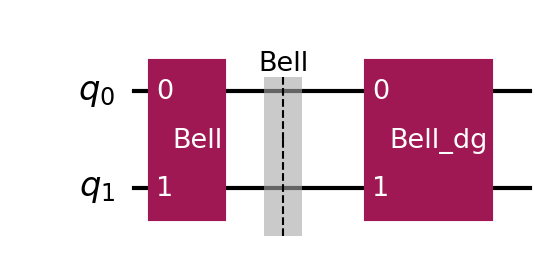

In [11]:
# ベル状態回路をゲート化
bell = QuantumCircuit(2, name="Bell")
bell.h(0)
bell.cx(0, 1)
bell_gate = bell.to_gate()

# 逆ゲートを作る
bell_inv = bell_gate.inverse()

# |00⟩ → Bell → Bell† → |00⟩ に戻るか確認
qc8 = QuantumCircuit(2)
qc8.append(bell_gate, [0, 1])    # ベル状態を作る
qc8.barrier(label="Bell")
qc8.append(bell_inv, [0, 1])     # 逆操作で戻す

sv8 = Statevector.from_instruction(qc8)
print("Bell → Bell† の結果:")
print("状態ベクトル:", np.array(sv8).round(4))
print()

# 元の |00⟩ に戻ったか確認
is_00 = np.allclose(np.array(sv8), [1, 0, 0, 0])
print(f"|00⟩ に戻った: {is_00}")
print()
print("→ ゲートの後にその inverse を掛けると、元の状態に完全に戻る。")

Bell → Bell† の結果:
状態ベクトル: [ 1.+0.j -0.+0.j  0.+0.j  0.+0.j]

|00⟩ に戻った: True

→ ゲートの後にその inverse を掛けると、元の状態に完全に戻る。


**コードの解説:**

- `bell_gate.inverse()`: ゲートの逆操作（随伴 $U^\dagger$）を返す。元の `bell_gate` は変更されず、新しいゲートオブジェクトが作られる。`.power()` や `.control()` も同様で、元のゲートを変えずに新しいオブジェクトを返す。
- `np.allclose(a, b)`: 2つの配列がほぼ等しいか判定する。浮動小数点の丸め誤差を許容して比較する。

`.inverse()` は任意のゲートに使える。後続の QFT ノートブックでは、`QFTGate(n).inverse()` で逆量子フーリエ変換を作り、QPE 回路の中で使う。